<a href="https://colab.research.google.com/github/athravkolekar07/athrav_07/blob/main/miniproject1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset
   Downloads  Reviews  App_Size  Updates  Rating  Popular
0       5000      120        20        2     3.5        0
1      10000      250        25        3     3.8        0
2      15000      320        18        3     4.0        0
3      20000      450        30        4     4.2        1
4      25000      550        22        5     4.3        1
5      30000      680        28        5     4.5        1
6      35000      750        24        6     4.6        1
7      40000      850        35        6     4.7        1
8      45000      920        27        7     4.8        1
9      50000     1000        32        8     5.0        1


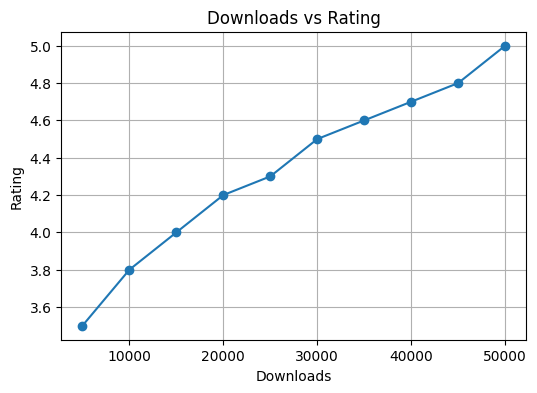

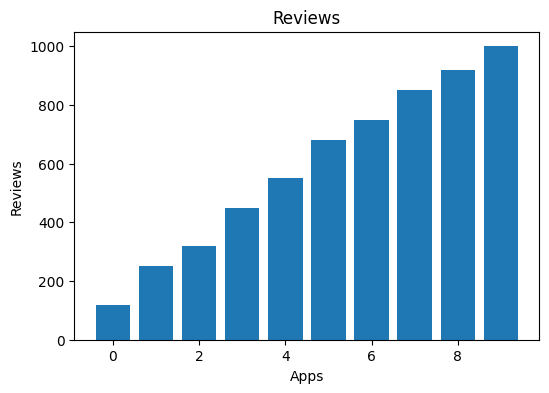

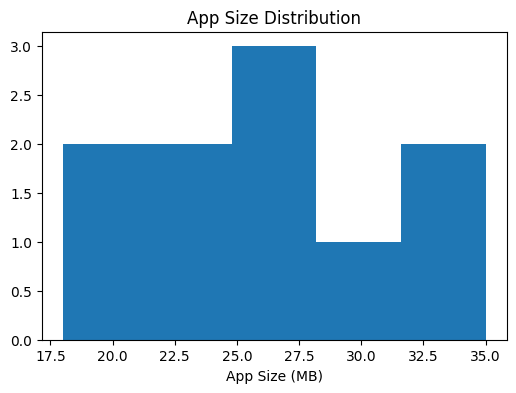

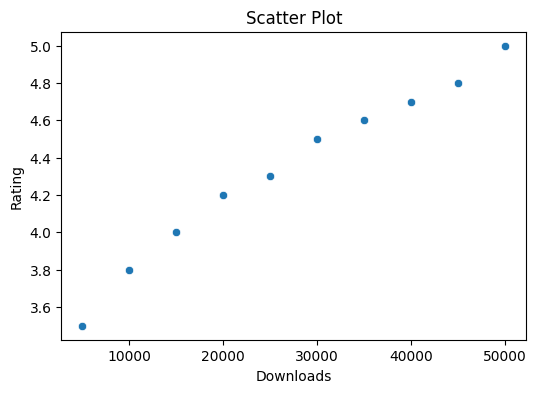


Linear Regression R2 Score = 0.9884220941674057
Predicted Rating = 4.687828193771433

Logistic Regression Accuracy = 0.5
Prediction : Popular App

KNN Accuracy = 1.0
KNN Result : Similar to Popular Apps


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score, accuracy_score

# Dataset

data = {
    "Downloads":[5000,10000,15000,20000,25000,30000,35000,40000,45000,50000],
    "Reviews":[120,250,320,450,550,680,750,850,920,1000],
    "App_Size":[20,25,18,30,22,28,24,35,27,32],
    "Updates":[2,3,3,4,5,5,6,6,7,8],
    "Rating":[3.5,3.8,4.0,4.2,4.3,4.5,4.6,4.7,4.8,5.0],
    "Popular":[0,0,0,1,1,1,1,1,1,1]
}

df = pd.DataFrame(data)

print("Dataset")
print(df)

# Data Visualization

plt.figure(figsize=(6,4))
plt.plot(df["Downloads"],df["Rating"],marker="o")
plt.title("Downloads vs Rating")
plt.xlabel("Downloads")
plt.ylabel("Rating")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.bar(df.index,df["Reviews"])
plt.title("Reviews")
plt.xlabel("Apps")
plt.ylabel("Reviews")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["App_Size"],bins=5)
plt.title("App Size Distribution")
plt.xlabel("App Size (MB)")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="Downloads",y="Rating",data=df)
plt.title("Scatter Plot")
plt.show()

X = df[["Downloads","Reviews","App_Size","Updates"]]
y = df["Rating"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

lr = LinearRegression()
lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

print("\nLinear Regression R2 Score =",r2_score(y_test,y_pred))

new_app = [[38000,800,26,6]]
pred_rating = lr.predict(new_app)

print("Predicted Rating =",pred_rating[0])

y2 = df["Popular"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y2,test_size=0.2,random_state=42
)

log_model = LogisticRegression()
log_model.fit(X_train,y_train)

pred = log_model.predict(X_test)

print("\nLogistic Regression Accuracy =",accuracy_score(y_test,pred))

popular = log_model.predict(new_app)

if popular[0]==1:
    print("Prediction : Popular App")
else:
    print("Prediction : Not Popular")

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)

knn_pred = knn.predict(X_test)

print("\nKNN Accuracy =",accuracy_score(y_test,knn_pred))

similar = knn.predict(new_app)

if similar[0]==1:
    print("KNN Result : Similar to Popular Apps")
else:
    print("KNN Result : Similar to Non-Popular Apps")